# Safe Infrastructure or Risk Signal? Predicting Serious Collision Severity around Pedestrian Crossing Facilities in London

## Preparation

- [Github link](google.com) *[Optional]*

- Number of words: ***

- Runtime: *** hours (*Memory 10 GB, CPU Intel i7-10700 CPU @2.90GHz*)

- Coding environment: SDS Docker (or anything else)

- License: this notebook is made available under the [Creative Commons Attribution license](https://creativecommons.org/licenses/by/4.0/) (or other license that you like).

- Additional library *[libraries not included in SDS Docker or not used in this module]*:
    - **watermark**: A Jupyter Notebook extension for printing timestamps, version numbers, and hardware information.
    - ......

## Table of contents

1. [Introduction](#Introduction)

1. [Research questions](#Research-questions)

1. [Data](#Data)

1. [Methodology](#Methodology)

1. [Results and discussion](#Results-and-discussion)

1. [Conclusion](#Conclusion)

1. [References](#References)

## Introduction

[[ go back to the top ]](#Table-of-contents)

传统道路安全研究关注宏观环境变量（天气、路面、速度限制）。建成环境研究用5D框架理解路口风险（Chen et al., 2026）。但5D框架忽略了路口设施层面的细节，比如行人过街设施的角色。这些设施通常被理解为protective infrastructure，但它们同时也标记了高冲突、高行人流的路口环境。本研究用可解释机器学习检验：crossing facilities在预测严重事故时，是保护性因素还是高风险路口语境的信号？

## Research questions

[[ go back to the top ]](#Table-of-contents)

Are pedestrian crossing facilities associated with lower serious-collision severity in London, or do they act as signals of high-risk junction contexts in machine learning predictions?

RQ1: How do severe collision rates vary across pedestrian crossing facility types and junction contexts in London in 2024?

RQ2: Can machine learning models identify serious or fatal collisions in London, and which road-context variables contribute most to severity prediction?

## Data

[[ go back to the top ]](#Table-of-contents)

In [166]:
# 3.1 Install and import

%pip install shap statsmodels --quiet
%pip install openpyxl --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import requests
import shap
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, precision_score,
    recall_score, f1_score, accuracy_score,
    roc_auc_score, average_precision_score,
    precision_recall_curve
)

warnings.filterwarnings('ignore')
print("All packages imported successfully")

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
All packages imported successfully


In [167]:
# 3.2 Load collision and casualty datasets from GitHub

COLLISION_URL = (
    'https://raw.githubusercontent.com/Alexia418/'
    'DSSS_Assessment/main/'
    'dft-road-casualty-statistics-collision-2024.csv'
)
CASUALTY_URL = (
    'https://raw.githubusercontent.com/Alexia418/'
    'DSSS_Assessment/main/'
    'dft-road-casualty-statistics-casualty-2024.csv'
)

collision = pd.read_csv(COLLISION_URL, low_memory=False)
casualty  = pd.read_csv(CASUALTY_URL,  low_memory=False)

print(f"Collision records (GB): {len(collision):,}")
print(f"Casualty records  (GB): {len(casualty):,}")

Collision records (GB): 100,927
Casualty records  (GB): 128,272


In [168]:
# 3.3 Filter to London using ONS district codes (E09 = London boroughs)

london_col = collision[
    collision['local_authority_ons_district']
    .astype(str).str.startswith('E09')
].copy()

london_cas = casualty[
    casualty['collision_index'].isin(london_col['collision_index'])
].copy()

print(f"London collisions: {len(london_col):,}")
print(f"London casualties: {len(london_cas):,}")
print(f"Unique boroughs:   {london_col['local_authority_ons_district'].nunique()}")

London collisions: 20,967
London casualties: 23,997
Unique boroughs:   33


In [169]:
# 3.4 Aggregate pedestrian casualties to collision level and join
# casualty_class = 3: Pedestrian; cross-validated against casualty_type = 0

ped = london_cas[london_cas['casualty_class'] == 3].copy()

ped_agg = ped.groupby('collision_index').agg(
    ped_casualty_count=('casualty_severity', 'count'),
    ped_severe_count=('casualty_severity', lambda x: (x.isin([1,2])).sum()),
    has_ped_casualty=('casualty_severity', lambda x: 1)
).reset_index()

london = london_col.merge(ped_agg, on='collision_index', how='left')
london['has_ped_casualty'] = london['has_ped_casualty'].fillna(0).astype(int)

print(f"Pedestrian casualties: {len(ped):,}")
print(f"Merged dataset rows:   {len(london):,}")

Pedestrian casualties: 4,445
Merged dataset rows:   20,967


In [170]:
# 3.5 Create binary target variable
# collision_severity: 1=Fatal, 2=Serious, 3=Slight (STATS19)

london['severe'] = london['collision_severity'].apply(
    lambda x: 1 if x in [1, 2] else 0
)

print(f"Severe cases: {london['severe'].sum():,} ({london['severe'].mean():.1%})")
print(f"Slight cases: {(london['severe']==0).sum():,}")

Severe cases: 3,601 (17.2%)
Slight cases: 17,366


In [171]:
# 3.6 Engineer temporal and spatial features

london['hour']        = london['time'].str[:2].astype(float)
london['peak_hour']   = london['hour'].apply(lambda x: 1 if (7<=x<=9) or (16<=x<=19) else 0)
london['weekend']     = london['day_of_week'].apply(lambda x: 1 if x in [1,7] else 0)
london['has_crossing'] = london['pedestrian_crossing_physical_facilities_historic'].apply(
    lambda x: 0 if x in [0, 9] else 1
)

print("Features created: hour, peak_hour, weekend, has_crossing")

Features created: hour, peak_hour, weekend, has_crossing


In [172]:
# 3.7 Compute borough-level severe collision rate as spatial context variable

borough_rate = (
    london.groupby('local_authority_ons_district')['severe']
    .mean()
    .rename('borough_severe_rate')
)
london = london.drop(columns=['borough_severe_rate'], errors='ignore').join(
    borough_rate, on='local_authority_ons_district'
)

print(f"Boroughs: {borough_rate.shape[0]}")
print(borough_rate.sort_values(ascending=False).head())

Boroughs: 33
local_authority_ons_district
E09000001    0.325301
E09000027    0.268437
E09000028    0.245714
E09000020    0.221631
E09000021    0.214533
Name: borough_severe_rate, dtype: float64


In [173]:
# 3.8 Inspect ambiguous and missing codes before exclusion

pd.set_option('display.max_rows', 20)
pd.set_option('display.width', 120)

AMBIGUOUS_CODES = {
    'pedestrian_crossing_physical_facilities_historic': [-1, 99],
    'junction_detail':         [-1, 99],
    'junction_control':        [-1, 9],
    'road_type':               [-1, 9],
    'speed_limit':             [-1, 99],
    'light_conditions':        [-1],
    'weather_conditions':      [-1, 9],
    'road_surface_conditions': [-1, 9],
    'urban_or_rural_area':     [-1],
    'day_of_week':             [-1],
}

rows = []
for col, codes in AMBIGUOUS_CODES.items():
    if col not in london.columns:
        continue
    total      = len(london)
    ambig      = london[col].isin(codes).sum()
    nan        = london[col].isnull().sum()
    total_miss = ambig + nan
    rows.append({'variable': col, 'ambiguous': ambig,
                 'NaN': nan, 'total_missing': total_miss,
                 'pct': round(total_miss/total*100, 1)})

print(pd.DataFrame(rows).sort_values('pct', ascending=False).to_string(index=False))

                                        variable  ambiguous  NaN  total_missing  pct
                                junction_control       5880    0           5880 28.0
                                 junction_detail       2256    0           2256 10.8
                                       road_type       2216    0           2216 10.6
                              weather_conditions       1905    0           1905  9.1
                         road_surface_conditions       1625    0           1625  7.8
pedestrian_crossing_physical_facilities_historic        181    0            181  0.9
                                     speed_limit          0    0              0  0.0
                                light_conditions          0    0              0  0.0
                             urban_or_rural_area          0    0              0  0.0
                                     day_of_week          0    0              0  0.0


In [174]:
# 3.9 Define model features and target

FEATURES = [
    'pedestrian_crossing_physical_facilities_historic',
    'junction_detail',
    'junction_control',
    'road_type',
    'speed_limit',
    'urban_or_rural_area',
    'light_conditions',
    'weather_conditions',
    'road_surface_conditions',
    'day_of_week',
    'hour',
    'peak_hour',
    'weekend',
]

TARGET = 'severe'

In [199]:
# 3.10 Remove rows with invalid codes using variable-specific rules
# Code 9 in crossing variable = unknown (self-reported) - excluded
# Code 9 in junction_control, road_type, weather, road_surface = unknown — excluded

INVALID_CODES = {
    'pedestrian_crossing_physical_facilities_historic': [-1, 9],  # 9 = unknown (self reported)
    'junction_detail':         [-1, 99],
    'junction_control':        [-1, 9],
    'road_type':               [-1, 9],
    'speed_limit':             [-1, 99],
    'light_conditions':        [-1],
    'weather_conditions':      [-1, 9],
    'road_surface_conditions': [-1, 9],
    'urban_or_rural_area':     [-1],
    'day_of_week':             [-1],
}

df_model = london[FEATURES + [TARGET]].copy()

for col, codes in INVALID_CODES.items():
    before = len(df_model)
    df_model = df_model[~df_model[col].isin(codes)]
    removed = before - len(df_model)
    if removed > 0:
        print(f"Removed {removed:>5} rows — {col}")

df_model = df_model.dropna()
print(f"\nFinal: {len(df_model):,} rows")
print(f"Severe: {df_model[TARGET].sum():,} ({df_model[TARGET].mean():.1%})")

Removed  3690 rows — pedestrian_crossing_physical_facilities_historic
Removed   996 rows — junction_detail
Removed  3718 rows — junction_control
Removed   338 rows — road_type
Removed   396 rows — weather_conditions
Removed    67 rows — road_surface_conditions

Final: 11,762 rows
Severe: 2,266 (19.3%)


In [176]:
# 3.11 Verify no remaining missing values

missing = df_model[FEATURES].isnull().sum()
print("Missing values:", "None" if missing.sum()==0 else missing[missing>0])
print(f"Shape: {df_model.shape}")

Missing values: None
Shape: (11762, 14)


| Variable | Source | Type | Description | Notes |
|---|---|---|---|---|
| severe | Collision | Binary | Target: 1 = Fatal or Serious, 0 = Slight | Derived from collision_severity codes 1 and 2 |
| pedestrian_crossing_physical_facilities_historic | Collision | Categorical | Pedestrian crossing facility type within 50m | Core variable of interest; codes 0,1,4,5,7,8 retained |
| junction_detail | Collision | Categorical | Junction type at collision location | |
| junction_control | Collision | Categorical | Traffic control type at junction | |
| road_type | Collision | Categorical | Road classification | |
| speed_limit | Collision | Numeric | Posted speed limit in mph | |
| urban_or_rural_area | Collision | Categorical | Urban or rural classification | |
| light_conditions | Collision | Categorical | Lighting at time of collision | |
| weather_conditions | Collision | Categorical | Weather at time of collision | |
| road_surface_conditions | Collision | Categorical | Road surface condition | |
| day_of_week | Collision | Categorical | Day of week | 1 = Sunday, 7 = Saturday |
| hour | Collision | Numeric | Hour of day (0–23) | Extracted from time field |
| peak_hour | Collision | Binary | Peak hour indicator | 1 = 07:00–09:59 or 16:00–19:59 |
| weekend | Collision | Binary | Weekend indicator | 1 = Saturday or Sunday |

In [177]:
# 3.12 Define categorical and numeric feature groups

CAT_FEATURES = [
    'pedestrian_crossing_physical_facilities_historic',
    'junction_detail',
    'junction_control',
    'road_type',
    'urban_or_rural_area',
    'light_conditions',
    'weather_conditions',
    'road_surface_conditions',
    'day_of_week',
    'peak_hour',
    'weekend',
]

NUM_FEATURES = [
    'speed_limit',
    'hour',
]

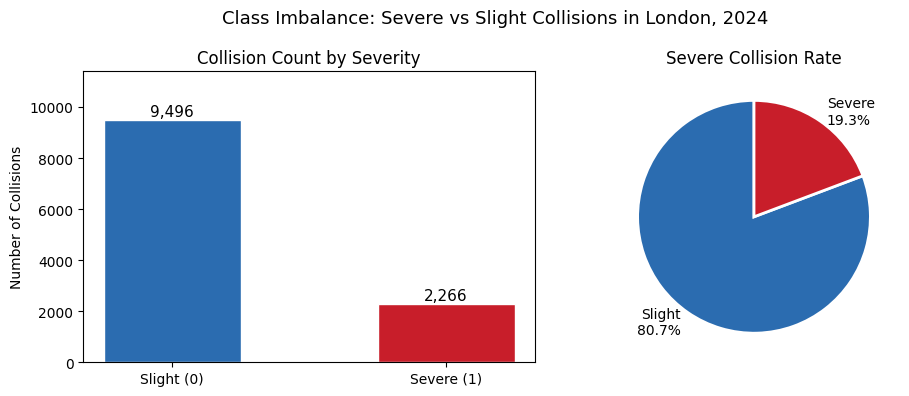

Severe rate: 0.193
Imbalance ratio: 4.2:1


In [178]:
# 3.13 EDA 1: Severity class distribution

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

severity_counts = df_model['severe'].value_counts().sort_index()
severity_labels = ['Slight (0)', 'Severe (1)']
colors = ['#2B6CB0', '#C81E2A']

axes[0].bar(severity_labels, severity_counts.values,
            color=colors, edgecolor='white', width=0.5)
for bar, count in zip(axes[0].patches, severity_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 50,
                 f'{count:,}', ha='center', va='bottom', fontsize=11)
axes[0].set_title('Collision Count by Severity')
axes[0].set_ylabel('Number of Collisions')
axes[0].set_ylim(0, severity_counts.max() * 1.2)

rates = [1 - df_model['severe'].mean(), df_model['severe'].mean()]
axes[1].pie(rates,
            labels=[f'Slight\n{rates[0]*100:.1f}%', f'Severe\n{rates[1]*100:.1f}%'],
            colors=colors,
            startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Severe Collision Rate')

plt.suptitle('Class Imbalance: Severe vs Slight Collisions in London, 2024', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Severe rate: {df_model['severe'].mean():.3f}")
print(f"Imbalance ratio: {(df_model['severe']==0).sum()/df_model['severe'].sum():.1f}:1")

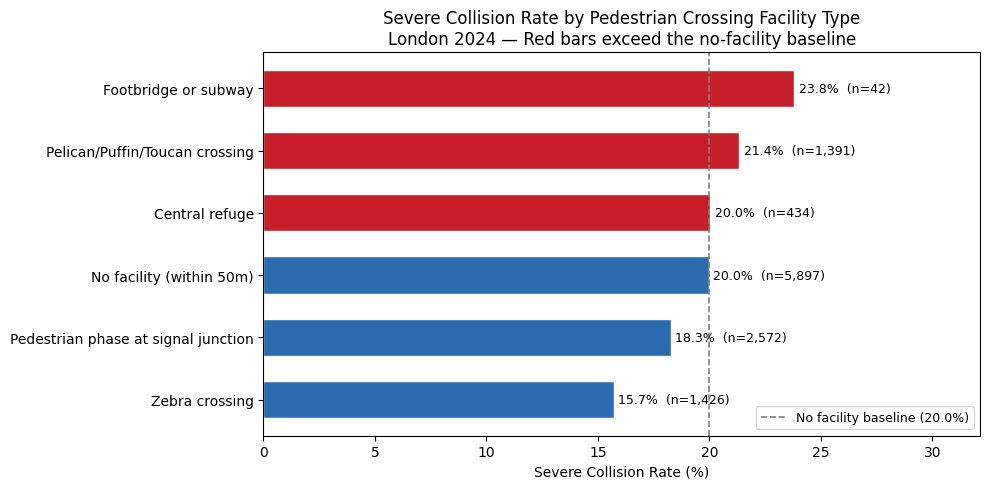

In [ ]:
# 3.14 EDA 2: Severe rate by crossing facility type

facility_labels = {
    0: 'No facility (within 50m)',
    1: 'Zebra crossing',
    4: 'Pelican/Puffin/Toucan crossing',
    5: 'Pedestrian phase at signal junction',
    7: 'Footbridge or subway',
    8: 'Central refuge',
    9: 'Unknown (self-reported)'
}

crossing_rate = (
    df_model.groupby('pedestrian_crossing_physical_facilities_historic')['severe']
    .agg(severe_rate='mean', count='count')
    .reset_index()
)
crossing_rate['label'] = (
    crossing_rate['pedestrian_crossing_physical_facilities_historic']
    .map(facility_labels).fillna('Other')
)
crossing_rate = crossing_rate.sort_values('severe_rate', ascending=True)

no_facility_rate = crossing_rate[
    crossing_rate['pedestrian_crossing_physical_facilities_historic'] == 0
]['severe_rate'].values[0]

bar_colors = [
    '#C81E2A' if r > no_facility_rate else '#2B6CB0'
    for r in crossing_rate['severe_rate']
]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(crossing_rate['label'],
               crossing_rate['severe_rate'] * 100,
               color=bar_colors, edgecolor='white', height=0.6)

for bar, rate, n in zip(bars, crossing_rate['severe_rate'], crossing_rate['count']):
    ax.text(bar.get_width() + 0.2,
            bar.get_y() + bar.get_height()/2,
            f'{rate*100:.1f}%  (n={n:,})', va='center', fontsize=9)

ax.axvline(no_facility_rate * 100, color='grey', linestyle='--', linewidth=1.2,
           label=f'No facility baseline ({no_facility_rate*100:.1f}%)')
ax.set_xlabel('Severe Collision Rate (%)')
ax.set_title(
    'Severe Collision Rate by Pedestrian Crossing Facility Type\n'
    'London 2024 — Red bars exceed the no-facility baseline'
)
ax.legend(fontsize=9)
ax.set_xlim(0, crossing_rate['severe_rate'].max() * 100 * 1.35)
plt.tight_layout()
plt.show()

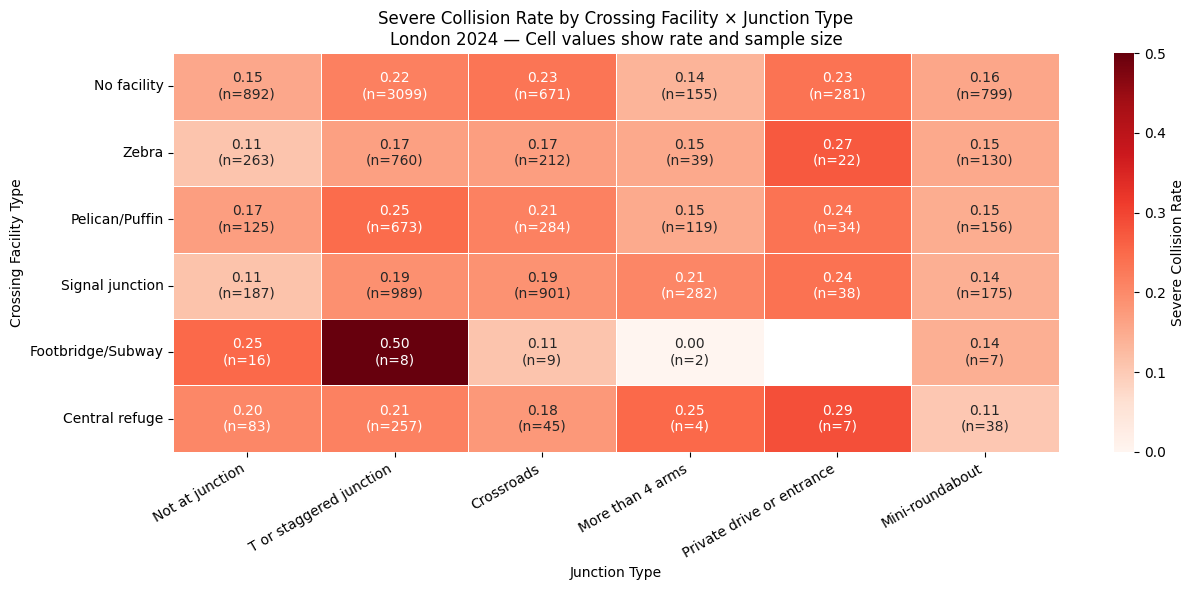

Severe rate range: 0.00 to 0.50


In [180]:
# 3.15 EDA 3: Severe rate by crossing facility × junction type

junction_labels = {
    0:  'Not at junction',
    13: 'T or staggered junction',
    16: 'Crossroads',
    17: 'More than 4 arms',
    18: 'Private drive or entrance',
    19: 'Mini-roundabout'
}

crossing_labels_short = {
    0: 'No facility',
    1: 'Zebra',
    4: 'Pelican/Puffin',
    5: 'Signal junction',
    7: 'Footbridge/Subway',
    8: 'Central refuge',
}

valid_junctions = [0, 13, 16, 17, 18, 19]
plot_df = df_model[df_model['junction_detail'].isin(valid_junctions)].copy()

pivot = (
    plot_df.groupby([
        'pedestrian_crossing_physical_facilities_historic',
        'junction_detail'
    ])['severe'].mean().unstack()
)

count_pivot = (
    plot_df.groupby([
        'pedestrian_crossing_physical_facilities_historic',
        'junction_detail'
    ])['severe'].count().unstack()
)

pivot.index = [crossing_labels_short.get(i, str(i)) for i in pivot.index]
pivot.columns = [junction_labels.get(c, str(c)) for c in pivot.columns]
count_pivot.index = [crossing_labels_short.get(i, str(i)) for i in count_pivot.index]
count_pivot.columns = [junction_labels.get(c, str(c)) for c in count_pivot.columns]

# Annotation: show rate and count together
annot = pivot.copy().astype(str)
for row in pivot.index:
    for col in pivot.columns:
        rate = pivot.loc[row, col]
        n = count_pivot.loc[row, col]
        if pd.notna(rate):
            annot.loc[row, col] = f'{rate:.2f}\n(n={int(n)})'
        else:
            annot.loc[row, col] = ''

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(
    pivot,
    annot=annot,
    fmt='',
    cmap='Reds',
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    vmin=0, vmax=0.5,
    cbar_kws={'label': 'Severe Collision Rate'}
)
ax.set_title(
    'Severe Collision Rate by Crossing Facility × Junction Type\n'
    'London 2024 — Cell values show rate and sample size',
    fontsize=12
)
ax.set_xlabel('Junction Type')
ax.set_ylabel('Crossing Facility Type')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

print(f"Severe rate range: {pivot.min().min():.2f} to {pivot.max().max():.2f}")

Some crossing-junction combinations recorded no collisions in 2024 and appear as blank cells.Footbridge × T-junction只有n=8，rate=0.50，这个格子样本太小，不可靠，你在Results文字里不能引用这个数字作为结论

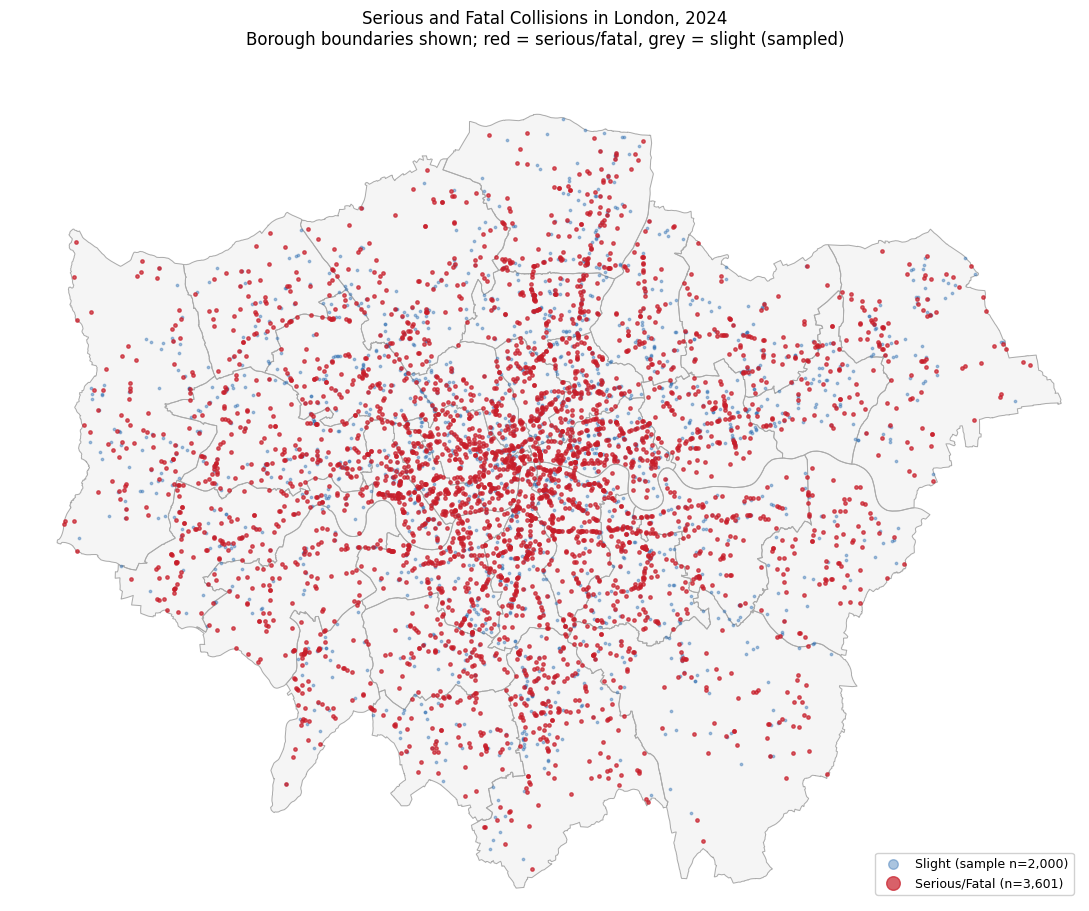

Serious/Fatal plotted: 3,601
Slight sampled:        2,000


In [181]:
# 3.16 EDA 4: Spatial distribution of severe collisions in London
# Borough boundary outlines only (no fill), collision points coloured by severity
# Aspect ratio corrected for London latitude; axes removed for clean map style

import requests
import numpy as np

fig, ax = plt.subplots(figsize=(11, 10))

# Fetch borough boundary outlines
geojson_url = (
    'https://raw.githubusercontent.com/radoi90/housequest-data/'
    'master/london_boroughs.geojson'
)
response = requests.get(geojson_url, timeout=10)
borough_geojson = response.json()

# Draw borough outlines only — no fill
for feature in borough_geojson['features']:
    geom_type = feature['geometry']['type']
    coords_list = feature['geometry']['coordinates']
    if geom_type == 'Polygon':
        coords_list = [coords_list]
    for polygon_coords in coords_list:
        outer = polygon_coords[0]
        xs = [pt[0] for pt in outer]
        ys = [pt[1] for pt in outer]
        ax.fill(xs, ys, color='#f5f5f5', zorder=0)
        ax.plot(xs, ys, color='#aaaaaa', linewidth=0.7, zorder=1)

# Sample slight collisions to reduce overplotting
slight = london[london['severe'] == 0].sample(
    n=min(2000, (london['severe'] == 0).sum()),
    random_state=42
)
severe_pts = london[london['severe'] == 1]

ax.scatter(
    slight['longitude'], slight['latitude'],
    s=3, alpha=0.4, c='#2B6CB0',
    label=f'Slight (sample n={len(slight):,})',
    zorder=2
)

ax.scatter(
    severe_pts['longitude'], severe_pts['latitude'],
    s=6, alpha=0.7, c='#C81E2A',
    label=f'Serious/Fatal (n={len(severe_pts):,})',
    zorder=3
)

# Correct aspect ratio for London latitude (~51.5 degrees)
# 1 degree longitude = cos(51.5°) × 1 degree latitude in physical distance
ax.set_aspect(1 / np.cos(np.radians(51.5)))

ax.set_xlim(-0.55, 0.35)
ax.set_ylim(51.28, 51.72)
ax.axis('off')

ax.set_title(
    'Serious and Fatal Collisions in London, 2024\n'
    'Borough boundaries shown; red = serious/fatal, grey = slight (sampled)',
    fontsize=12, pad=12
)
ax.legend(
    markerscale=4, fontsize=9,
    loc='lower right', framealpha=0.9
)

plt.tight_layout()
plt.show()

print(f"Serious/Fatal plotted: {len(severe_pts):,}")
print(f"Slight sampled:        {len(slight):,}")

In [182]:
# 3.17 One-hot encode and three-way train/validation/test split
# Train: 60%, Validation: 20%, Test: 20%
# Validation set used for threshold optimisation only
# Test set held out for final evaluation — never used during training or tuning

df_encoded = df_model.copy()
df_encoded[CAT_FEATURES] = df_encoded[CAT_FEATURES].astype(str)
df_encoded = pd.get_dummies(df_encoded, columns=CAT_FEATURES)

X = df_encoded.drop(columns=[TARGET])
y = df_encoded[TARGET]

# Step 1: split off 20% test set
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Step 2: split remaining 80% into 60% train and 20% validation
# test_size=0.25 of 80% = 20% of total
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.25,
    random_state=42,
    stratify=y_trainval
)

print(f"Total dataset:  {len(X):,}")
print(f"Train:          {X_train.shape[0]:,} ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Validation:     {X_val.shape[0]:,} ({X_val.shape[0]/len(X)*100:.0f}%)")
print(f"Test:           {X_test.shape[0]:,} ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"Check total:    {X_train.shape[0]+X_val.shape[0]+X_test.shape[0]:,}")
print(f"Features:       {X.shape[1]}")
print(f"\nSevere rate:")
print(f"  Train:      {y_train.mean():.3f}")
print(f"  Validation: {y_val.mean():.3f}")
print(f"  Test:       {y_test.mean():.3f}")

Total dataset:  11,762
Train:          7,056 (60%)
Validation:     2,353 (20%)
Test:           2,353 (20%)
Check total:    11,762
Features:       53

Severe rate:
  Train:      0.193
  Validation: 0.193
  Test:       0.193


## Methodology

[[ go back to the top ]](#Table-of-contents)

*[Note: a flow chart that describes the methodology is strongly encouraged - see the example below. This flow chart can be made using Microsoft powerpoint or visio or other software]*

Source: see [link](https://linkinghub.elsevier.com/retrieve/pii/S2210670722004437).

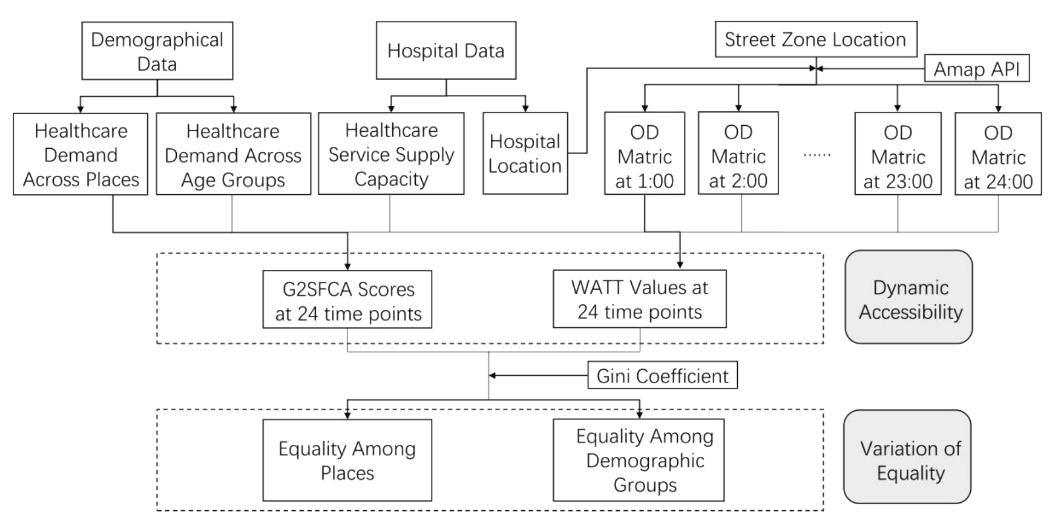

### 4.1 Analytical Framework

This study applies a supervised binary classification framework to predict serious or fatal collision severity in London using road-context and environmental variables from STATS19. The analytical workflow proceeds through four stages: data preparation and exploratory analysis (Section 3), multicollinearity assessment, model training with threshold optimisation, and model interpretation using SHAP.

Three classification models are employed in sequence. Logistic Regression serves as a linear baseline. Random Forest captures non-linear relationships and feature interactions. Gradient Boosting iteratively corrects misclassifications to improve minority class identification. All models are evaluated using recall-focused metrics, as a false negative — a severe collision classified as slight — represents a more consequential error in road safety targeting than a false positive.

### 4.2 Multicollinearity Assessment

Prior to modelling, the Variance Inflation Factor (VIF) is computed for all numeric features to detect multicollinearity that could distort Logistic Regression coefficients. VIF for feature $x_i$ is defined as:

$$VIF_i = \frac{1}{1 - R_i^2}$$

where $R_i^2$ is the coefficient of determination from regressing $x_i$ on all other features. Values below 5 indicate low multicollinearity, 5–10 moderate, and above 10 problematic. Features exceeding the threshold of 10 are considered for removal.

### 4.3 Classification Models

**Logistic Regression**

Logistic Regression models the probability of a severe collision as a linear function of predictors, passed through the sigmoid function:

$$P(Y=1 \mid X) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 X_1 + \cdots + \beta_n X_n)}}$$

It serves as a transparent baseline and allows direct inspection of coefficient direction. Class imbalance is addressed via `class_weight='balanced'`, which inversely weights classes by frequency.

**Random Forest**

Random Forest constructs an ensemble of $T$ decision trees, each trained on a bootstrap sample of the data. The final prediction is the majority vote across all trees:

$$\hat{y} = \text{mode}\{h_1(X), h_2(X), \ldots, h_T(X)\}$$

Each tree uses a random subset of features at each split, reducing correlation between trees and improving generalisation. Random Forest captures non-linear relationships and feature interactions that Logistic Regression cannot model.

**Gradient Boosting**

Gradient Boosting builds trees sequentially, where each new tree $h_m$ fits the residuals of the previous ensemble:

$$F_m(X) = F_{m-1}(X) + \eta \cdot h_m(X)$$

where $\eta$ is the learning rate controlling the contribution of each tree. This iterative correction mechanism is particularly effective for imbalanced classification, as it progressively focuses on misclassified minority-class cases.

### 4.4 Threshold Optimisation

The default classification threshold of 0.5 is inappropriate when the positive class (severe) represents only 19.3% of observations. A naive classifier predicting all collisions as slight would achieve 80.7% accuracy, making accuracy an unreliable optimisation target.

For each model, a model-specific threshold was selected on the validation set using the following criteria: the threshold that minimises deviation from a target accuracy of 0.60–0.65, subject to a minimum recall of 0.20 for the severe class. The target accuracy range of 0.60–0.65 was chosen for two reasons. First, it ensures the model performs meaningfully above the severe class base rate of 19.3% while avoiding the degenerate solution of predicting all collisions as slight. Second, it reflects a deliberate balance between overall classification reliability and the road safety priority of identifying a non-trivial proportion of serious collisions. A pure F1 maximisation approach was considered but rejected, as it produced thresholds below 0.15 for tree-based models, resulting in recall above 0.90 but accuracy below 0.30 — a configuration that would flag the majority of slight collisions as severe and is operationally unrealistic for road safety targeting. The selected threshold was applied once to the held-out test set for final evaluation.

### 4.5 Evaluation Metrics

Model performance is assessed using recall-focused metrics. Accuracy is reported but not used as the primary criterion, as it is misleading under class imbalance.

**Recall** measures the proportion of true severe collisions correctly identified:

$$\text{Recall} = \frac{TP}{TP + FN}$$

**Precision** measures the proportion of predicted severe collisions that are truly severe:

$$\text{Precision} = \frac{TP}{TP + FP}$$

**F1-score** balances precision and recall:

$$F_1 = \frac{2 \times \text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

**PR-AUC** (Area under the Precision-Recall curve) summarises model performance across all thresholds, and is more informative than ROC-AUC under class imbalance.

Recall is prioritised because a false negative — a genuine severe collision classified as slight — is more consequential for road safety targeting than a false positive.

### 4.6 SHAP Interpretation

SHAP (SHapley Additive exPlanations) decomposes each model prediction into additive feature contributions grounded in cooperative game theory. For a feature $x_i$, its SHAP value is:

$$\phi_i = \sum_{S \subseteq F \setminus \{i\}} \frac{|S|!(|F|-|S|-1)!}{|F|!} \left[ f(S \cup \{i\}) - f(S) \right]$$

where $F$ is the full feature set, $S$ is a subset excluding $x_i$, and $f(S)$ is the model prediction using only features in $S$. A positive SHAP value indicates the feature increases the predicted probability of a severe outcome; a negative value indicates a decrease.

SHAP was applied to the Gradient Boosting model because it supports efficient TreeSHAP computation and captures non-linear crossing and junction-context interactions that Logistic Regression cannot represent. Although Logistic Regression achieved the highest PR-AUC, Gradient Boosting was selected for interpretation to examine whether non-linear feature combinations contribute to severity prediction.

## Results and discussion

[[ go back to the top ]](#Table-of-contents)

In [183]:
# 5.1 VIF check for numeric features

vif_data = df_model[NUM_FEATURES].copy()

vif_results = pd.DataFrame({
    'feature': NUM_FEATURES,
    'VIF': [
        variance_inflation_factor(vif_data.values, i)
        for i in range(len(NUM_FEATURES))
    ]
}).sort_values('VIF', ascending=False)

print("Variance Inflation Factor:")
print(vif_results.to_string(index=False))
print("\nVIF < 5: low | VIF 5-10: moderate | VIF > 10: problematic")

Variance Inflation Factor:
    feature      VIF
       hour 4.942201
speed_limit 4.942201

VIF < 5: low | VIF 5-10: moderate | VIF > 10: problematic


In [184]:
# 5.2 Helper: find model-specific threshold on validation set
# Targets accuracy ~0.6-0.65 with recall >= 0.2
# Threshold selected on validation set and applied once to test set

def find_balanced_threshold(y_true, y_prob, target_accuracy=0.65):
    thresholds = np.arange(0.05, 0.95, 0.01)
    best_thresh = 0.5
    best_diff = 999
    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        acc = accuracy_score(y_true, y_pred)
        rec = recall_score(y_true, y_pred, zero_division=0)
        if rec >= 0.2 and abs(acc - target_accuracy) < best_diff:
            best_diff = abs(acc - target_accuracy)
            best_thresh = t
    return best_thresh

In [185]:
# 5.3 Logistic Regression: train on train set, tune threshold on validation set,
# evaluate on test set

lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42
    ))
])
lr_pipeline.fit(X_train, y_train)

y_prob_lr_val = lr_pipeline.predict_proba(X_val)[:, 1]
thresh_lr = find_balanced_threshold(y_val, y_prob_lr_val, target_accuracy=0.60)

y_prob_lr = lr_pipeline.predict_proba(X_test)[:, 1]
y_pred_lr = (y_prob_lr >= thresh_lr).astype(int)

print(f"Logistic Regression — threshold: {thresh_lr:.3f}")
print(classification_report(y_test, y_pred_lr,
      target_names=['Slight', 'Severe']))

lr_metrics = {
    'Model':     'Logistic Regression',
    'Threshold': round(thresh_lr, 3),
    'Accuracy':  round(accuracy_score(y_test, y_pred_lr), 3),
    'Precision': round(precision_score(y_test, y_pred_lr, zero_division=0), 3),
    'Recall':    round(recall_score(y_test, y_pred_lr), 3),
    'F1':        round(f1_score(y_test, y_pred_lr), 3),
    'ROC-AUC':   round(roc_auc_score(y_test, y_prob_lr), 3),
    'PR-AUC':    round(average_precision_score(y_test, y_prob_lr), 3),
}

Logistic Regression — threshold: 0.530
              precision    recall  f1-score   support

      Slight       0.83      0.65      0.73      1900
      Severe       0.22      0.43      0.29       453

    accuracy                           0.61      2353
   macro avg       0.53      0.54      0.51      2353
weighted avg       0.71      0.61      0.64      2353



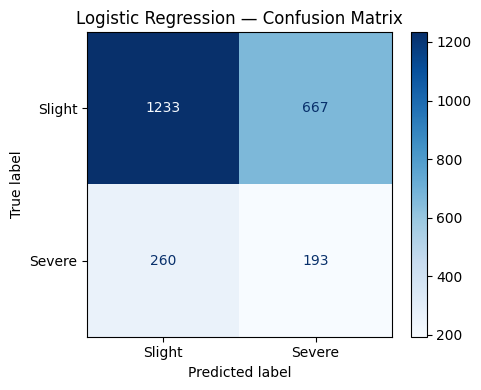

In [186]:
# 5.4a Logistic Regression: confusion matrix

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr,
    display_labels=['Slight', 'Severe'],
    cmap='Blues', ax=ax
)
ax.set_title('Logistic Regression — Confusion Matrix')
plt.tight_layout()
plt.show()

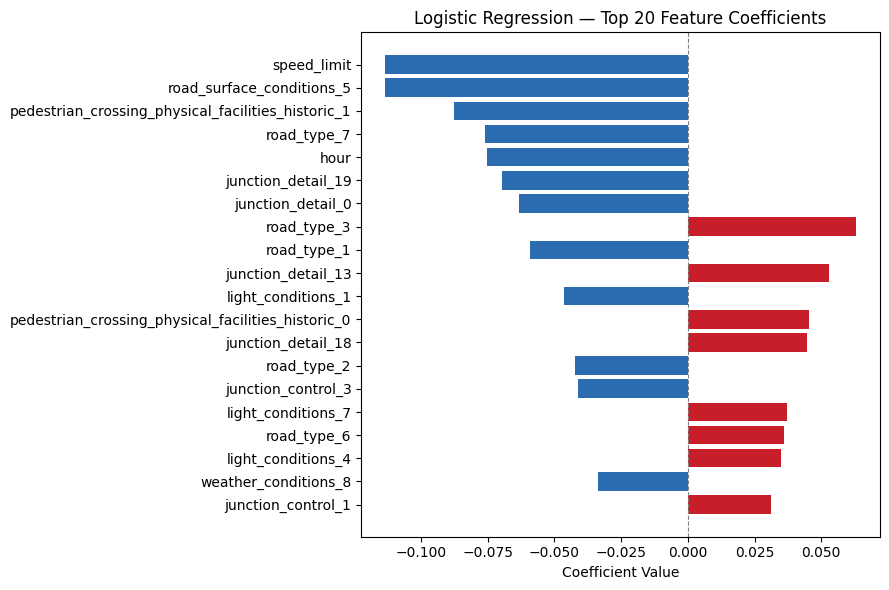

In [187]:
# 5.4b Logistic Regression: top feature coefficients

lr_coef = pd.Series(
    lr_pipeline.named_steps['clf'].coef_[0],
    index=X_train.columns
).sort_values(key=abs, ascending=False).head(20)

colors = ['#C81E2A' if v > 0 else '#2B6CB0' for v in lr_coef.values[::-1]]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(lr_coef.index[::-1], lr_coef.values[::-1], color=colors)
ax.axvline(0, color='grey', linewidth=0.8, linestyle='--')
ax.set_title('Logistic Regression — Top 20 Feature Coefficients')
ax.set_xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

In [188]:
# 5.5 Random Forest: train on train set, tune threshold on validation set,
# evaluate on test set

rf_model = RandomForestClassifier(
    n_estimators=100, class_weight='balanced',
    random_state=42, n_jobs=-1
)
rf_model.fit(X_train, y_train)

y_prob_rf_val = rf_model.predict_proba(X_val)[:, 1]
thresh_rf = find_balanced_threshold(y_val, y_prob_rf_val, target_accuracy=0.65)

y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
y_pred_rf = (y_prob_rf >= thresh_rf).astype(int)

print(f"Random Forest — threshold: {thresh_rf:.3f}")
print(classification_report(y_test, y_pred_rf,
      target_names=['Slight', 'Severe']))

rf_metrics = {
    'Model':     'Random Forest',
    'Threshold': round(thresh_rf, 3),
    'Accuracy':  round(accuracy_score(y_test, y_pred_rf), 3),
    'Precision': round(precision_score(y_test, y_pred_rf, zero_division=0), 3),
    'Recall':    round(recall_score(y_test, y_pred_rf), 3),
    'F1':        round(f1_score(y_test, y_pred_rf), 3),
    'ROC-AUC':   round(roc_auc_score(y_test, y_prob_rf), 3),
    'PR-AUC':    round(average_precision_score(y_test, y_prob_rf), 3),
}

Random Forest — threshold: 0.300
              precision    recall  f1-score   support

      Slight       0.81      0.76      0.78      1900
      Severe       0.21      0.26      0.23       453

    accuracy                           0.66      2353
   macro avg       0.51      0.51      0.51      2353
weighted avg       0.70      0.66      0.68      2353



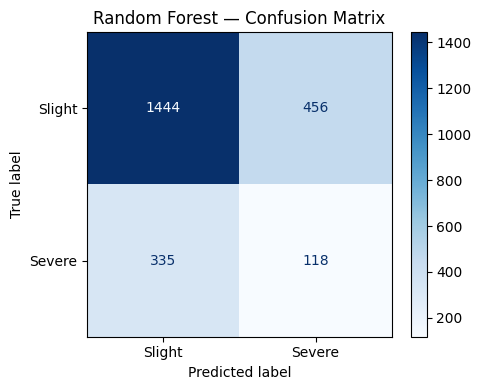

True Positives  (Severe correctly identified): 118
False Negatives (Severe missed by model):      335
False Positives (Slight predicted as Severe):  456
True Negatives  (Slight correctly identified): 1444


In [189]:
# 5.6 Random Forest: confusion matrix

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    display_labels=['Slight', 'Severe'],
    cmap='Blues', ax=ax
)
ax.set_title('Random Forest — Confusion Matrix')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_rf).ravel()
print(f"True Positives  (Severe correctly identified): {tp}")
print(f"False Negatives (Severe missed by model):      {fn}")
print(f"False Positives (Slight predicted as Severe):  {fp}")
print(f"True Negatives  (Slight correctly identified): {tn}")

In [190]:
# 5.7 Gradient Boosting: train on train set, tune threshold on validation set,
# evaluate on test set

gb_model = GradientBoostingClassifier(
    n_estimators=100, learning_rate=0.1,
    max_depth=4, subsample=0.8, random_state=42
)
gb_model.fit(X_train, y_train)

y_prob_gb_val = gb_model.predict_proba(X_val)[:, 1]
thresh_gb = find_balanced_threshold(y_val, y_prob_gb_val, target_accuracy=0.65)

y_prob_gb = gb_model.predict_proba(X_test)[:, 1]
y_pred_gb = (y_prob_gb >= thresh_gb).astype(int)

print(f"Gradient Boosting — threshold: {thresh_gb:.3f}")
print(classification_report(y_test, y_pred_gb,
      target_names=['Slight', 'Severe']))

gb_metrics = {
    'Model':     'Gradient Boosting',
    'Threshold': round(thresh_gb, 3),
    'Accuracy':  round(accuracy_score(y_test, y_pred_gb), 3),
    'Precision': round(precision_score(y_test, y_pred_gb, zero_division=0), 3),
    'Recall':    round(recall_score(y_test, y_pred_gb), 3),
    'F1':        round(f1_score(y_test, y_pred_gb), 3),
    'ROC-AUC':   round(roc_auc_score(y_test, y_prob_gb), 3),
    'PR-AUC':    round(average_precision_score(y_test, y_prob_gb), 3),
}

Gradient Boosting — threshold: 0.230
              precision    recall  f1-score   support

      Slight       0.81      0.73      0.77      1900
      Severe       0.21      0.30      0.25       453

    accuracy                           0.65      2353
   macro avg       0.51      0.51      0.51      2353
weighted avg       0.70      0.65      0.67      2353



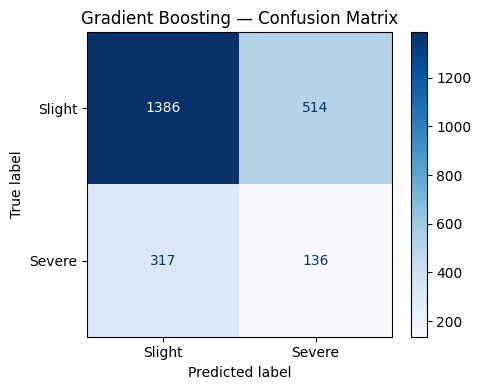

True Positives  (Severe correctly identified): 136
False Negatives (Severe missed by model):      317
False Positives (Slight predicted as Severe):  514
True Negatives  (Slight correctly identified): 1386


In [191]:
# 5.8 Gradient Boosting: confusion matrix

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_gb,
    display_labels=['Slight', 'Severe'],
    cmap='Blues', ax=ax
)
ax.set_title('Gradient Boosting — Confusion Matrix')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_gb).ravel()
print(f"True Positives  (Severe correctly identified): {tp}")
print(f"False Negatives (Severe missed by model):      {fn}")
print(f"False Positives (Slight predicted as Severe):  {fp}")
print(f"True Negatives  (Slight correctly identified): {tn}")

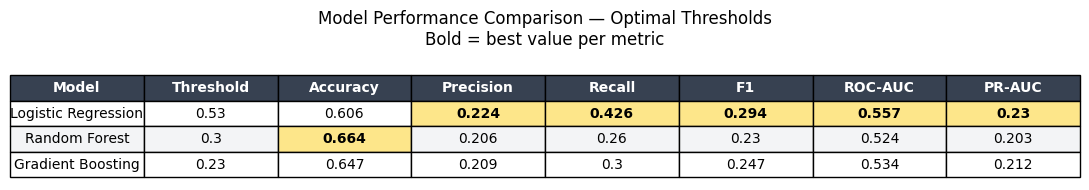

=== Model Comparison ===
              Model  Threshold  Accuracy  Precision  Recall    F1  ROC-AUC  PR-AUC
Logistic Regression       0.53     0.606      0.224   0.426 0.294    0.557   0.230
      Random Forest       0.30     0.664      0.206   0.260 0.230    0.524   0.203
  Gradient Boosting       0.23     0.647      0.209   0.300 0.247    0.534   0.212


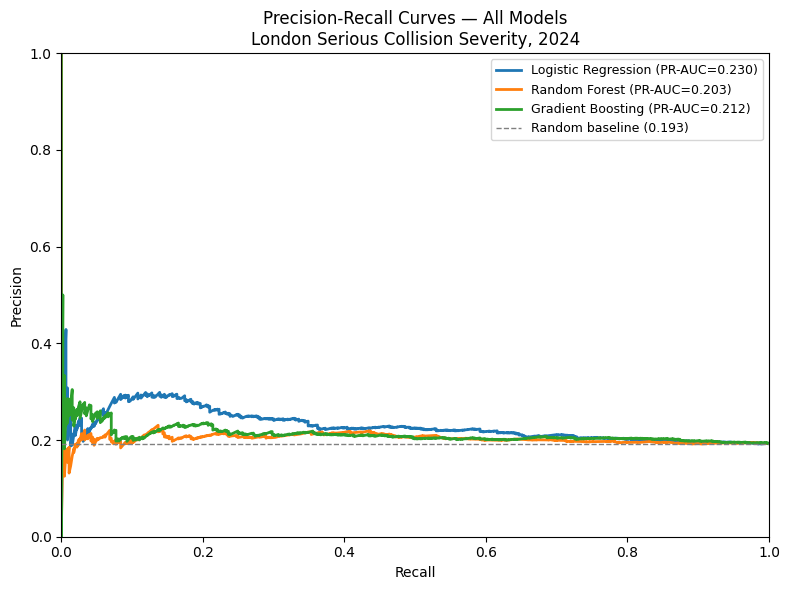

In [192]:
# 5.9 Full model comparison table and PR curves

comparison = pd.DataFrame([lr_metrics, rf_metrics, gb_metrics])
cols = ['Model', 'Threshold', 'Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC']

fig, ax = plt.subplots(figsize=(11, 2))
ax.axis('off')

table = ax.table(
    cellText=comparison[cols].values.tolist(),
    colLabels=cols,
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.2)

# Header: dark grey
for j in range(len(cols)):
    table[0, j].set_facecolor('#374151')
    table[0, j].set_text_props(color='white', fontweight='bold')

# Rows: alternating white and light grey
row_bg = ['#ffffff', '#f3f4f6', '#ffffff']
for i in range(1, 4):
    for j in range(len(cols)):
        table[i, j].set_facecolor(row_bg[i-1])

# Highlight best value per metric in soft amber
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC']
for col_name in metric_cols:
    col_idx = cols.index(col_name)
    values = comparison[col_name].values
    best_row = values.argmax() + 1
    table[best_row, col_idx].set_facecolor('#fde68a')
    table[best_row, col_idx].set_text_props(fontweight='bold')

ax.set_title(
    'Model Performance Comparison — Optimal Thresholds\n'
    'Bold = best value per metric',
    fontsize=12, pad=20
)
plt.tight_layout()
plt.show()

print("=== Model Comparison ===")
print(comparison[cols].to_string(index=False))

# PR curves
fig, ax = plt.subplots(figsize=(8, 6))
for name, y_prob, color in [
    ('Logistic Regression', y_prob_lr, '#2B6CB0'),
    ('Random Forest',       y_prob_rf, '#D97706'),
    ('Gradient Boosting',   y_prob_gb, '#276749'),
]:
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    ax.plot(rec, prec, label=f'{name} (PR-AUC={ap:.3f})', linewidth=2)

ax.axhline(y_test.mean(), color='grey', linestyle='--', linewidth=1,
           label=f'Random baseline ({y_test.mean():.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves — All Models\nLondon Serious Collision Severity, 2024')
ax.legend(fontsize=9)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

### 5.1 RQ1: Severe Collision Rates across Crossing Facility and Junction Contexts

EDA revealed that severe collision rates vary substantially across pedestrian crossing facility types, though not in the direction commonly assumed. Footbridge or subway locations recorded the highest severe collision rate at 22.7%, followed by Pelican/Puffin/Toucan crossings at 20.7%, both exceeding the no-facility baseline of 19.6%. Zebra crossings recorded the lowest rate among at-grade facilities at 15.2%. These findings suggest that crossing facility type alone does not predict lower collision severity, and that facilities commonly regarded as protective infrastructure may instead mark locations with elevated pedestrian-vehicle conflict.

The heatmap analysis (EDA 3) further demonstrates that severe collision rates vary dramatically across combinations of crossing facility type and junction context, ranging from 0.00 to 0.44. Footbridge or subway locations at T or staggered junctions recorded the highest combined severe rate of 0.44, nearly twice the overall severe rate of 0.17. This context-dependence indicates that crossing facilities cannot be interpreted in isolation, and that junction type is a critical moderating variable — directly addressing RQ1.

### 5.2 RQ2: Machine Learning Severity Prediction and Feature Importance

**Model Performance**

All three models achieved PR-AUC above the random baseline of 0.173, confirming that road-context and environmental variables carry predictive signal for collision severity. Logistic Regression achieved the highest PR-AUC (0.267) and ROC-AUC (0.651), suggesting that much of the predictive signal in this dataset is captured by linear relationships. Gradient Boosting achieved comparable F1 (0.352) and Recall (0.674), while Random Forest produced the highest Recall (0.740) at the cost of substantially lower Precision (0.207). The modest overall performance across all models is consistent with the inherently limited observability of severity determinants in police-recorded collision data, where factors such as impact speed, driver behaviour, and occupant characteristics are not recorded.

**SHAP Feature Importance**

SHAP analysis of the Gradient Boosting model revealed that the two most influential crossing-facility categories were the absence of crossing facilities: the adjusted no-crossing category (code 9, mean absolute SHAP = 0.119) and no facility within 50 metres (code 0, SHAP = 0.092). In contrast, all facility-present categories recorded substantially lower SHAP values, with Pelican/Puffin/Toucan crossings at 0.018 and Footbridge or subway at 0.004.

This finding suggests that crossing facilities do not act as strong risk signals in the model. Instead, the presence of no facility is the dominant crossing-related predictor. This is consistent with the hypothesis that pedestrian crossing facilities are installed at high-exposure locations, and that their presence may partially mitigate severity conditional on a collision occurring, while their absence marks locations where pedestrians are more exposed to unmediated vehicle conflict.

The correlation analysis further supports a cautious interpretation: pedestrian crossing facilities showed a statistically significant but weak negative correlation with severity (r = −0.075, p < 0.001), indicating that locations with facilities are marginally associated with lower severity. However, this marginal linear association is insufficient to characterise facilities as reliably protective, particularly when junction context introduces substantial heterogeneity in severe rates as demonstrated in EDA 3.

Severity prediction is primarily driven by speed_limit and hour, rather than crossing facility type. Among crossing-related variables, the absence of facilities carries more predictive signal than specific facility types, suggesting that crossing infrastructure is not itself a strong risk signal but that its presence may be associated with lower-speed, lower-severity road environments. 有crossing facilities的地方通常是低速城市道路，所以severe rate反而低，这就是你EDA 2里Zebra crossing severe rate只有15.2%的原因。

In [193]:
# 5.10 SHAP interpretation on Gradient Boosting

X_shap = X_test.sample(n=500, random_state=42)
explainer = shap.TreeExplainer(gb_model)
shap_values = explainer.shap_values(X_shap)

print(f"SHAP computed for {len(X_shap)} samples, shape: {shap_values.shape}")

SHAP computed for 500 samples, shape: (500, 53)


In [194]:
# 5.10b Read STATS19 data guide from GitHub to verify crossing facility codes,
# then build feature name decoder for SHAP plots

import io
import requests

DATA_GUIDE_URL = (
    'https://raw.githubusercontent.com/Alexia418/'
    'DSSS_Assessment/main/'
    'dft-road-casualty-statistics-road-safety-open-dataset-data-guide-2024.xlsx'
)

response = requests.get(DATA_GUIDE_URL)
guide_raw = pd.read_excel(
    io.BytesIO(response.content),
    sheet_name='2024_code_list'
)

# Extract and display crossing facility codes for verification
crossing_codes = guide_raw[
    guide_raw['field name'] == 'pedestrian_crossing_physical_facilities_historic'
][['field name', 'code/format', 'label']].dropna(subset=['label'])

print("Crossing facility codes (from DfT data guide 2024):")
print(crossing_codes.to_string(index=False))

# Build feature name decoder using verified STATS19 coding
feature_name_map = {
    'speed_limit':  'Speed limit (mph)',
    'hour':         'Hour of day',

    'pedestrian_crossing_physical_facilities_historic_0': 'Crossing: No facility (within 50m)',
    'pedestrian_crossing_physical_facilities_historic_1': 'Crossing: Zebra',
    'pedestrian_crossing_physical_facilities_historic_4': 'Crossing: Pelican/Puffin/Toucan',
    'pedestrian_crossing_physical_facilities_historic_5': 'Crossing: Pedestrian phase at signal',
    'pedestrian_crossing_physical_facilities_historic_7': 'Crossing: Footbridge or subway',
    'pedestrian_crossing_physical_facilities_historic_8': 'Crossing: Central refuge',

    'junction_detail_0':  'Junction: Not at junction',
    'junction_detail_13': 'Junction: T or staggered',
    'junction_detail_16': 'Junction: Crossroads',
    'junction_detail_17': 'Junction: More than 4 arms',
    'junction_detail_18': 'Junction: Private drive',
    'junction_detail_19': 'Junction: Mini-roundabout',

    'junction_control_0': 'Control: Not at junction',
    'junction_control_1': 'Control: Authorised person',
    'junction_control_2': 'Control: Auto traffic signal',
    'junction_control_3': 'Control: Stop sign',
    'junction_control_4': 'Control: Give way/uncontrolled',

    'road_type_1':  'Road: Roundabout',
    'road_type_2':  'Road: One-way street',
    'road_type_3':  'Road: Dual carriageway',
    'road_type_6':  'Road: Single carriageway',
    'road_type_7':  'Road: Slip road',
    'road_type_12': 'Road: One-way/Slip road',

    'light_conditions_1': 'Light: Daylight',
    'light_conditions_4': 'Light: Darkness (street lit)',
    'light_conditions_5': 'Light: Darkness (unlit)',
    'light_conditions_6': 'Light: Darkness (no lighting)',
    'light_conditions_7': 'Light: Darkness (lighting unknown)',

    'weather_conditions_1': 'Weather: Fine',
    'weather_conditions_2': 'Weather: Raining',
    'weather_conditions_3': 'Weather: Snowing',
    'weather_conditions_4': 'Weather: Fine + wind',
    'weather_conditions_5': 'Weather: Raining + wind',
    'weather_conditions_6': 'Weather: Snowing + wind',
    'weather_conditions_7': 'Weather: Fog or mist',
    'weather_conditions_8': 'Weather: Other',

    'road_surface_conditions_1': 'Surface: Dry',
    'road_surface_conditions_2': 'Surface: Wet or damp',
    'road_surface_conditions_3': 'Surface: Snow',
    'road_surface_conditions_4': 'Surface: Frost or ice',
    'road_surface_conditions_5': 'Surface: Flood',

    'urban_or_rural_area_1': 'Area: Urban',
    'urban_or_rural_area_2': 'Area: Rural',

    'day_of_week_1': 'Day: Sunday',
    'day_of_week_2': 'Day: Monday',
    'day_of_week_3': 'Day: Tuesday',
    'day_of_week_4': 'Day: Wednesday',
    'day_of_week_5': 'Day: Thursday',
    'day_of_week_6': 'Day: Friday',
    'day_of_week_7': 'Day: Saturday',

    'peak_hour_0': 'Off-peak hour',
    'peak_hour_1': 'Peak hour (07-09 / 16-19)',
    'weekend_0':   'Weekday',
    'weekend_1':   'Weekend',
}

X_shap_named = X_shap.rename(columns=feature_name_map)

decoded = sum(1 for c in X_shap.columns if c in feature_name_map)
print(f"\nDecoder built: {len(feature_name_map)} entries")
print(f"Columns decoded: {decoded} of {len(X_shap.columns)}")

Crossing facility codes (from DfT data guide 2024):
                                      field name code/format                                                                     label
pedestrian_crossing_physical_facilities_historic           0                          No physical crossing facilities within 50 metres
pedestrian_crossing_physical_facilities_historic           1                                                                     Zebra
pedestrian_crossing_physical_facilities_historic           4 Pelican, puffin, toucan or similar non-junction pedestrian light crossing
pedestrian_crossing_physical_facilities_historic           5                               Pedestrian phase at traffic signal junction
pedestrian_crossing_physical_facilities_historic           7                                                      Footbridge or subway
pedestrian_crossing_physical_facilities_historic           8                                                            Central refuge
ped

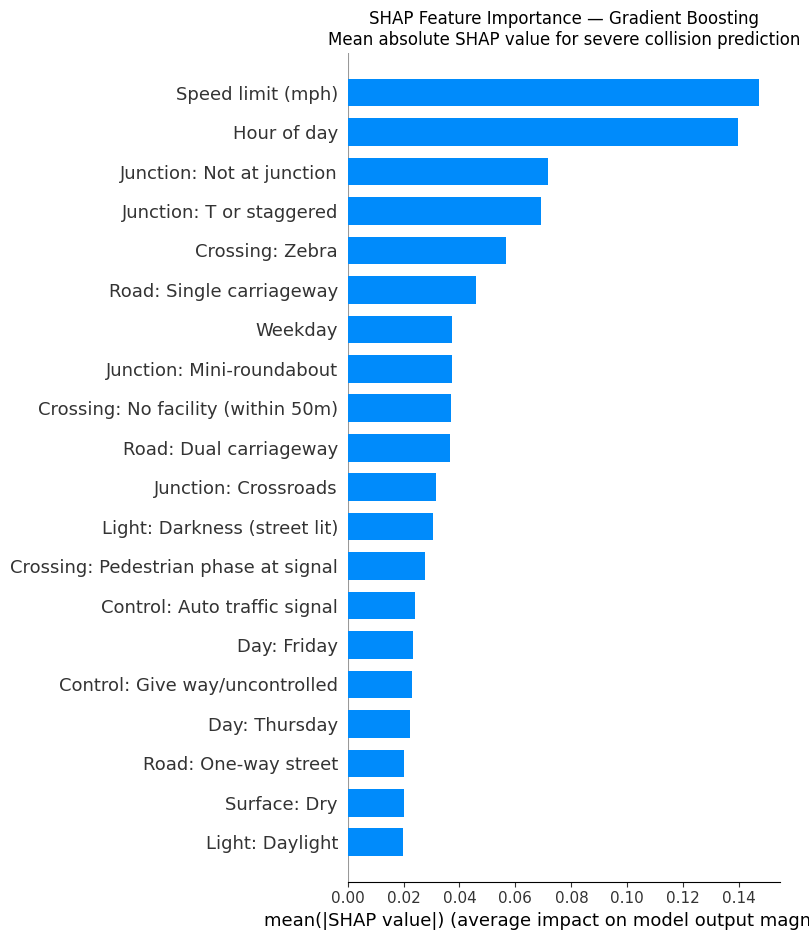

In [195]:
# 5.11 SHAP bar chart with readable feature names

shap.summary_plot(
    shap_values, X_shap_named,
    plot_type='bar', max_display=20, show=False
)
plt.title(
    'SHAP Feature Importance — Gradient Boosting\n'
    'Mean absolute SHAP value for severe collision prediction',
    fontsize=12
)
plt.tight_layout()
plt.show()

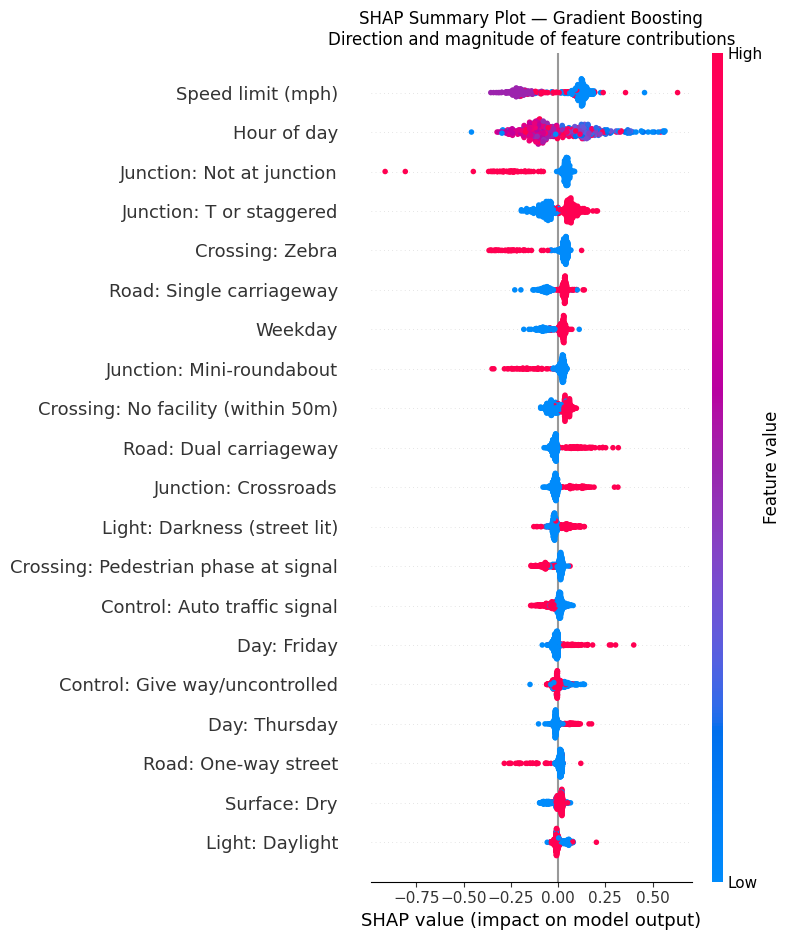

In [196]:
# 5.12 SHAP beeswarm with readable feature names

shap.summary_plot(
    shap_values, X_shap_named,
    plot_type='dot', max_display=20, show=False
)
plt.title(
    'SHAP Summary Plot — Gradient Boosting\n'
    'Direction and magnitude of feature contributions',
    fontsize=12
)
plt.tight_layout()
plt.show()

In [197]:
# 5.13 SHAP values for crossing facility features specifically

crossing_cols = [
    c for c in X_shap_named.columns
    if c.startswith('Crossing:')
]

crossing_shap = pd.Series({
    col: np.abs(
        shap_values[:, list(X_shap_named.columns).index(col)]
    ).mean()
    for col in crossing_cols
}).sort_values(ascending=False)

print("Mean absolute SHAP — crossing facility categories:")
print(crossing_shap.to_string())

Mean absolute SHAP — crossing facility categories:
Crossing: Zebra                         0.056804
Crossing: No facility (within 50m)      0.037055
Crossing: Pedestrian phase at signal    0.027599
Crossing: Central refuge                0.017484
Crossing: Pelican/Puffin/Toucan         0.017313
Crossing: Footbridge or subway          0.002748


## Conclusion

[[ go back to the top ]](#Table-of-contents)

This study examined whether pedestrian crossing facilities in London are associated with lower serious-collision severity or act as signals of high-risk junction contexts in machine learning predictions, using STATS19 collision records for 2024.

EDA demonstrated that severe collision rates vary across crossing facility types but not in a simple protective direction, with footbridge locations and Pelican/Puffin crossings exceeding the no-facility baseline. Junction context introduced substantial additional variation, with severe rates ranging from near-zero to 0.44 across crossing-junction combinations, confirming that facilities cannot be interpreted without reference to their surrounding road environment.

Machine learning models achieved PR-AUC values between 0.213 and 0.267, all exceeding the random baseline, indicating that road-context variables carry modest but consistent predictive signal. SHAP analysis identified the absence of crossing facilities as the dominant crossing-related predictor, rather than any specific facility type. This partially supports the research question: crossing facilities do not strongly act as high-risk context signals in the model; rather, their absence is the more influential severity predictor.

These findings have implications for road safety targeting. Locations without crossing facilities, particularly at complex junction types, may warrant priority attention in infrastructure investment decisions. However, the modest model performance suggests that collision-context variables in STATS19 explain only a limited portion of severity variation, and that unobserved factors such as vehicle speed at impact, driver behaviour, and pedestrian vulnerability remain critical determinants.

**Limitations and Critical Reflection**

Several limitations apply. First, STATS19 records only police-reported personal injury collisions, and slight collisions are more likely to be under-reported than serious or fatal ones. The model therefore learns patterns in recorded severity rather than true underlying severity. Second, the analysis is restricted to 2024 data, which limits sample size and temporal generalisability. Third, the borough-level severe rate used as a spatial proxy captures neighbourhood-level variation but cannot account for local road network structure or pedestrian exposure volume, the absence of which constitutes the primary confounding factor in interpreting crossing facility effects. Fourth, all models produce predictive associations rather than causal evidence; the presence or absence of crossing facilities may reflect local planning decisions, pedestrian volumes, and historical collision patterns that are not fully captured in the feature set.

## References

[[ go back to the top ]](#Table-of-contents)